# Ensembles of Neural Networks
### MECH 559 - Systems Optimization - L04

A single network's training is stochastic: random initialization and a
nonconvex loss mean two networks trained on the *same* data can land on
different solutions. This notebook turns that instability into a feature by
training an **ensemble** of networks and using their spread as a cheap,
model-free uncertainty estimate -- the neural-network analogue of the Kriging
prediction variance from the previous notebook.

## Learning objectives

By the end, you should be able to:

1. Show that identically-architected networks trained on the same data from different random seeds disagree, especially away from the training data.
2. Combine an ensemble into a mean prediction and a spread (standard deviation) that shrinks near training data and grows away from it.
3. Explain bagging (bootstrap aggregation) as a second source of diversity, alongside random initialization.
4. Show that the ensemble mean's test error is lower than a typical individual member's -- the variance-reduction benefit of averaging.
5. Apply an ensemble to the 2-D Rosenbrock function and compare its uncertainty map to Kriging's.

> **Classroom rhythm:** I will pause at each **Predict** prompt before running the next cell.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import qmc

try:
    import ipywidgets as widgets
    from IPython.display import display
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False

rng = np.random.default_rng(559)
plt.rcParams.update({"font.size": 11, "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})
COLORS = {"true": "#264653", "train": "black", "band": "#EDAE49", "mean": "#D1495B"}
print(f"Optional widgets available: {WIDGETS_AVAILABLE}")


def forrester(x):
    return (6 * x - 2) ** 2 * np.sin(12 * x - 4)


def lhs_1d(p, seed=0):
    sampler = qmc.LatinHypercube(d=1, seed=seed)
    return sampler.random(p).ravel()


# --- the same small feedforward network as the previous notebook ---

def init_params(layer_sizes, seed):
    param_rng = np.random.default_rng(seed)
    params = []
    for n_in, n_out in zip(layer_sizes[:-1], layer_sizes[1:]):
        W = param_rng.normal(scale=np.sqrt(2.0 / n_in), size=(n_out, n_in))
        b = np.zeros(n_out)
        params.append([W, b])
    return params


def tanh_act(z):
    return np.tanh(z)


def tanh_grad(z):
    return 1.0 - np.tanh(z) ** 2


def forward(params, X, act):
    n_layers = len(params)
    cache = [(None, X)]
    A = X
    for l, (W, b) in enumerate(params):
        Z = A @ W.T + b
        A = act(Z) if l < n_layers - 1 else Z
        cache.append((Z, A))
    return cache


def predict(params, X, act):
    return forward(params, X, act)[-1][1]


def backward(params, cache, y, act_grad):
    n_layers = len(params)
    p = y.shape[0]
    grads = [[None, None] for _ in range(n_layers)]
    dA = (2.0 / p) * (cache[-1][1] - y)
    for l in reversed(range(n_layers)):
        Z, A_prev = cache[l + 1][0], cache[l][1]
        dZ = dA if l == n_layers - 1 else dA * act_grad(Z)
        W, _ = params[l]
        grads[l][0] = dZ.T @ A_prev
        grads[l][1] = dZ.sum(axis=0)
        dA = dZ @ W
    return grads


def clip_grads(grads, max_norm=5.0):
    total_norm = np.sqrt(sum(np.sum(dW**2) + np.sum(db**2) for dW, db in grads))
    if total_norm > max_norm:
        scale = max_norm / total_norm
        for dW, db in grads:
            dW *= scale
            db *= scale
    return grads


def train(params, X, y, lr=0.05, epochs=3000, momentum=0.9):
    velocity = [[np.zeros_like(W), np.zeros_like(b)] for W, b in params]
    for _ in range(epochs):
        cache = forward(params, X, tanh_act)
        grads = clip_grads(backward(params, cache, y, tanh_grad))
        for l in range(len(params)):
            velocity[l][0] = momentum * velocity[l][0] - lr * grads[l][0]
            velocity[l][1] = momentum * velocity[l][1] - lr * grads[l][1]
            params[l][0] = params[l][0] + velocity[l][0]
            params[l][1] = params[l][1] + velocity[l][1]
    return params


p_train = 10
x_train_ens = lhs_1d(p_train, seed=8).reshape(-1, 1)
y_train_ens = forrester(x_train_ens)
x_dense_ens = np.linspace(0, 1, 300).reshape(-1, 1)
print(f"Training budget: p={p_train} points")

Optional widgets available: True
Training budget: p=10 points


---
## 1. Same architecture, same data, different random seed

> **Predict:** away from the training points, will independently-initialized
> networks agree closely, or diverge?

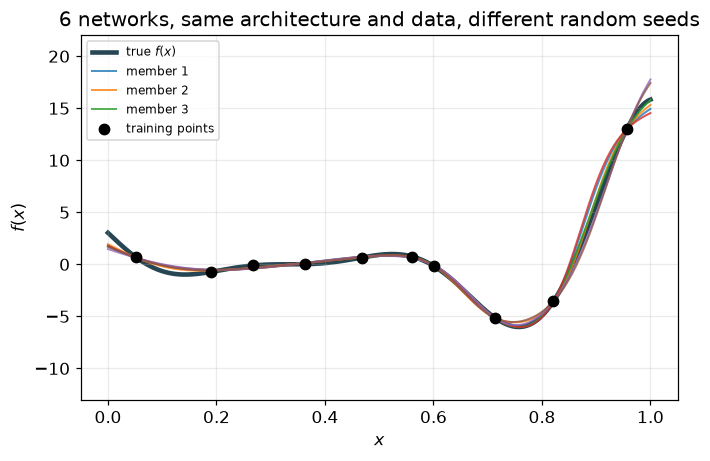

disagreement (std across members) near x=0.5: 0.02


In [3]:
def train_member(seed, X=x_train_ens, y=y_train_ens, width=16):
    params = init_params([X.shape[1], width, 1], seed)
    return train(params, X, y)


n_members_demo = 6
member_seeds = range(100, 100 + n_members_demo)
members_demo = [train_member(seed) for seed in member_seeds]

fig, ax = plt.subplots(figsize=(7, 4.3))
ax.plot(x_dense_ens, forrester(x_dense_ens), color=COLORS["true"], lw=3, label="true $f(x)$", zorder=1)
for i, params in enumerate(members_demo):
    y_hat = predict(params, x_dense_ens, tanh_act)
    ax.plot(x_dense_ens, y_hat, lw=1.3, alpha=0.8, label=f"member {i+1}" if i < 3 else None)
ax.scatter(x_train_ens, y_train_ens, color=COLORS["train"], zorder=5, s=45, label="training points")
ax.set(xlabel="$x$", ylabel="$f(x)$", ylim=(-13, 22),
       title=f"{n_members_demo} networks, same architecture and data, different random seeds")
ax.legend(fontsize=8); plt.show()

predictions_demo = np.hstack([predict(p, x_dense_ens, tanh_act) for p in members_demo])
spread_at_gap = predictions_demo[np.argmin(np.abs(x_dense_ens - 0.5))].std()
print(f"disagreement (std across members) near x=0.5: {spread_at_gap:.2f}")

The members agree closely near training points but visibly disagree in the
gaps -- exactly the same *shape* of behaviour as Kriging's uncertainty, but it
emerged here purely from training randomness, with no explicit probabilistic
model.

---
## 2. Ensemble mean and spread as an uncertainty estimate

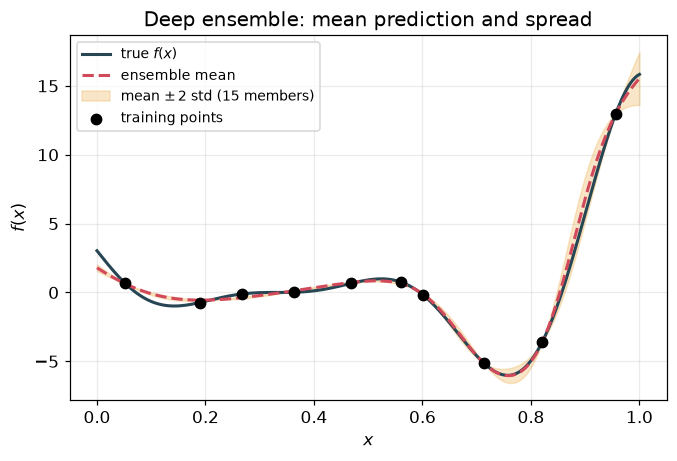

average spread near training points: 0.020
average spread over the whole domain: 0.141


In [4]:
def build_ensemble(n_members, X, y, width=16, seed0=0, bootstrap=False, boot_rng=None):
    members = []
    for k in range(n_members):
        if bootstrap:
            idx = boot_rng.integers(0, len(X), size=len(X))
            X_k, y_k = X[idx], y[idx]
        else:
            X_k, y_k = X, y
        members.append(train_member(seed0 + k, X_k, y_k, width))
    return members


def ensemble_predict(members, X_query):
    predictions = np.hstack([predict(m, X_query, tanh_act) for m in members])
    return predictions.mean(axis=1, keepdims=True), predictions.std(axis=1, keepdims=True)


ensemble = build_ensemble(n_members=15, X=x_train_ens, y=y_train_ens, width=16, seed0=200)
mean_pred, std_pred = ensemble_predict(ensemble, x_dense_ens)

fig, ax = plt.subplots(figsize=(7, 4.3))
ax.plot(x_dense_ens, forrester(x_dense_ens), color=COLORS["true"], lw=2, label="true $f(x)$")
ax.plot(x_dense_ens, mean_pred, color=COLORS["mean"], lw=2, ls="--", label="ensemble mean")
ax.fill_between(x_dense_ens.ravel(), mean_pred.ravel() - 2 * std_pred.ravel(),
                mean_pred.ravel() + 2 * std_pred.ravel(), color=COLORS["band"], alpha=0.3,
                label="mean $\\pm\\,2$ std (15 members)")
ax.scatter(x_train_ens, y_train_ens, color=COLORS["train"], zorder=5, s=45, label="training points")
ax.set(xlabel="$x$", ylabel="$f(x)$", title="Deep ensemble: mean prediction and spread")
ax.legend(fontsize=9); plt.show()

mean_std_at_train = np.interp(x_train_ens.ravel(), x_dense_ens.ravel(), std_pred.ravel()).mean()
mean_std_overall = std_pred.mean()
print(f"average spread near training points: {mean_std_at_train:.3f}")
print(f"average spread over the whole domain: {mean_std_overall:.3f}")
assert mean_std_at_train < mean_std_overall, "spread should be smaller near training data than on average"

Unlike Kriging, this spread has **no** guarantee of vanishing exactly at
training points (each member only fits the data approximately, and to a
different local optimum) -- but empirically it is still noticeably smaller
there, which is often good enough to flag untrustworthy extrapolation.

---
## 3. A second source of diversity: bagging

**Bootstrap aggregation (bagging)** resamples the training set *with
replacement* for every ensemble member, in addition to a different random
initialization.

> **Predict:** will bagging make the ensemble's uncertainty band wider or
> narrower than using the same 10 points for every member?

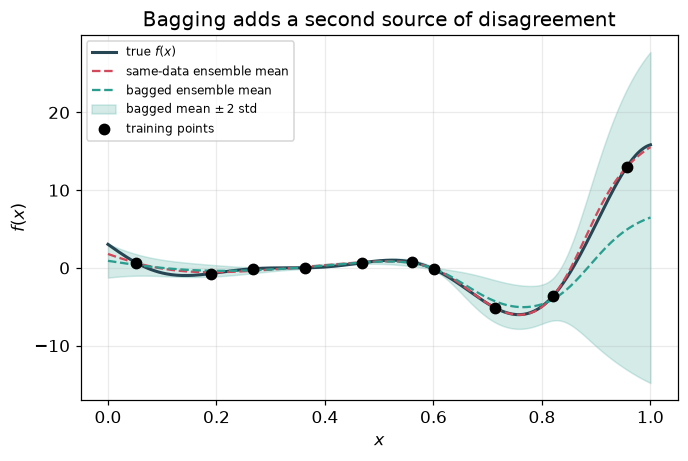

average spread, same-data ensemble: 0.141
average spread, bagged ensemble:    1.527


In [5]:
boot_rng = np.random.default_rng(321)
bagged_ensemble = build_ensemble(n_members=15, X=x_train_ens, y=y_train_ens, width=16, seed0=300,
                                 bootstrap=True, boot_rng=boot_rng)
mean_bagged, std_bagged = ensemble_predict(bagged_ensemble, x_dense_ens)

fig, ax = plt.subplots(figsize=(7, 4.3))
ax.plot(x_dense_ens, forrester(x_dense_ens), color=COLORS["true"], lw=2, label="true $f(x)$")
ax.plot(x_dense_ens, mean_pred, color=COLORS["mean"], lw=1.5, ls="--", label="same-data ensemble mean")
ax.plot(x_dense_ens, mean_bagged, color="#2A9D8F", lw=1.5, ls="--", label="bagged ensemble mean")
ax.fill_between(x_dense_ens.ravel(), mean_bagged.ravel() - 2 * std_bagged.ravel(),
                mean_bagged.ravel() + 2 * std_bagged.ravel(), color="#2A9D8F", alpha=0.2,
                label="bagged mean $\\pm\\,2$ std")
ax.scatter(x_train_ens, y_train_ens, color=COLORS["train"], zorder=5, s=45, label="training points")
ax.set(xlabel="$x$", ylabel="$f(x)$", title="Bagging adds a second source of disagreement")
ax.legend(fontsize=8); plt.show()

print(f"average spread, same-data ensemble: {std_pred.mean():.3f}")
print(f"average spread, bagged ensemble:    {std_bagged.mean():.3f}")

Resampling the (already tiny) 10-point training set means some members never
see certain points at all, adding genuine data-driven disagreement on top of
the random-initialization disagreement -- typically widening the band
further. With larger data sets bagging is the dominant, and often preferred,
source of ensemble diversity.

---
## 4. Does averaging actually help accuracy?

> **Predict:** should the ensemble mean's test RMSE be better, worse, or the
> same as a *typical single* member's test RMSE?

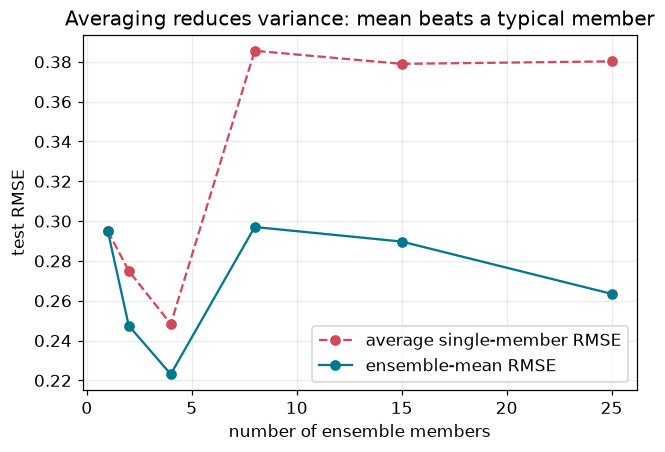

typical single-member RMSE: 0.380
15-member ensemble-mean RMSE: 0.290


In [6]:
x_test_ens = rng.uniform(0, 1, size=200).reshape(-1, 1)
y_test_ens = forrester(x_test_ens)


def rmse(y_hat, y_true):
    return np.sqrt(np.mean((y_hat - y_true) ** 2))


member_sizes = [1, 2, 4, 8, 15, 25]
mean_rmses = []
single_member_rmses = []
for n_members in member_sizes:
    members = build_ensemble(n_members=n_members, X=x_train_ens, y=y_train_ens, width=16, seed0=400)
    mean_test, _ = ensemble_predict(members, x_test_ens)
    mean_rmses.append(rmse(mean_test, y_test_ens))
    single_member_rmses.append(np.mean([rmse(predict(m, x_test_ens, tanh_act), y_test_ens) for m in members]))

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(member_sizes, single_member_rmses, "o--", color="#D1495B", label="average single-member RMSE")
ax.plot(member_sizes, mean_rmses, "o-", color="#00798C", label="ensemble-mean RMSE")
ax.set(xlabel="number of ensemble members", ylabel="test RMSE",
       title="Averaging reduces variance: mean beats a typical member")
ax.legend(); plt.show()

print(f"typical single-member RMSE: {single_member_rmses[-1]:.3f}")
print(f"15-member ensemble-mean RMSE: {mean_rmses[member_sizes.index(15)]:.3f}")
assert mean_rmses[-1] < np.mean(single_member_rmses), "the ensemble mean should beat the average single member"

---
## 5. A 2-D application: Rosenbrock

Exactly as with Kriging, we can map the ensemble's mean and spread over a 2-D
input space.

In [7]:
def rosenbrock(X):
    x1, x2 = X[:, 0], X[:, 1]
    return ((1 - x1) ** 2 + 100 * (x2 - x1**2) ** 2).reshape(-1, 1)


bounds_2d = [(-2.0, 2.0), (-1.0, 3.0)]
sampler_2d = qmc.LatinHypercube(d=2, seed=9)
unit = sampler_2d.random(25)
lower, upper = np.array(bounds_2d)[:, 0], np.array(bounds_2d)[:, 1]
X_train_2d = lower + unit * (upper - lower)
y_train_2d = rosenbrock(X_train_2d)

# scale inputs to [0,1]^2 and the output to a comparable range -- networks train
# far more reliably on well-scaled data (recall the polynomial-regression notebook)
X_train_2d_scaled = (X_train_2d - lower) / (upper - lower)
y_scale = y_train_2d.std()
y_train_2d_scaled = y_train_2d / y_scale

ensemble_2d = [train_member(seed=500 + k, X=X_train_2d_scaled, y=y_train_2d_scaled, width=24)
              for k in range(15)]

x1_grid = np.linspace(*bounds_2d[0], 100)
x2_grid = np.linspace(*bounds_2d[1], 100)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
X_grid = np.column_stack([X1.ravel(), X2.ravel()])
X_grid_scaled = (X_grid - lower) / (upper - lower)

mean_grid, std_grid = ensemble_predict(ensemble_2d, X_grid_scaled)
mean_grid = (mean_grid * y_scale).reshape(X1.shape)
std_grid = (std_grid * y_scale).reshape(X1.shape)
true_grid = rosenbrock(X_grid).reshape(X1.shape)

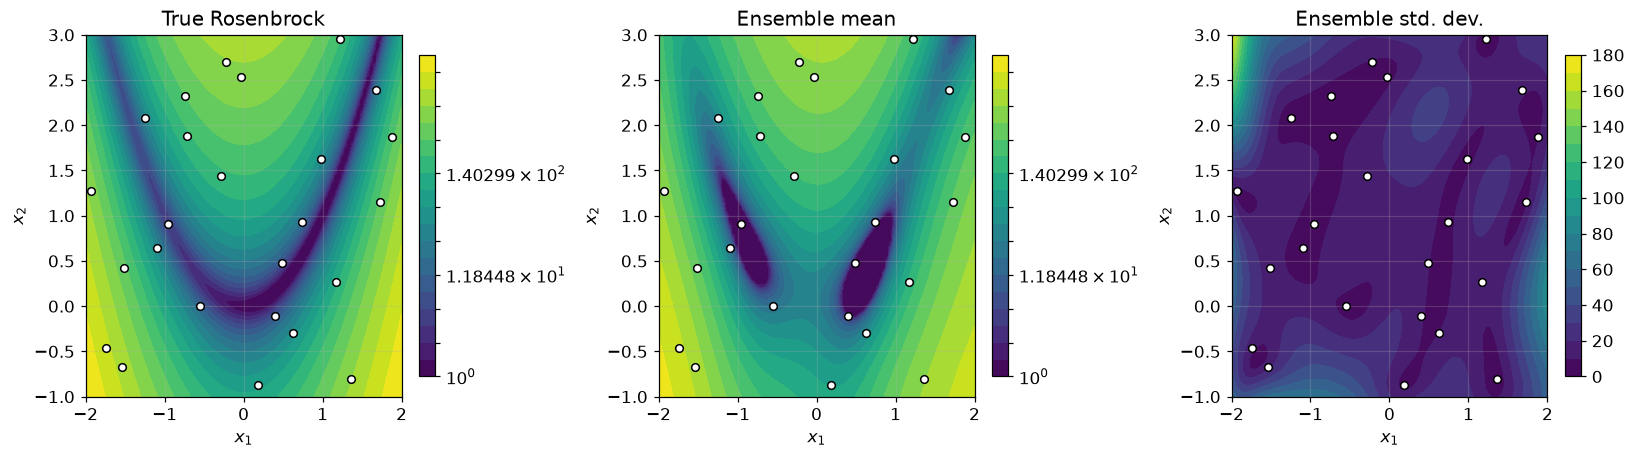

ensemble-mean held-out RMSE on the Rosenbrock function: 89.32
average ensemble std at training points: 8.80; average over the domain: 21.95


In [8]:
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
levels = np.geomspace(1, true_grid.max(), 20)
for ax, surface, title in zip(axes, [true_grid, mean_grid, std_grid],
                              ["True Rosenbrock", "Ensemble mean", "Ensemble std. dev."]):
    if title == "Ensemble std. dev.":
        contour = ax.contourf(X1, X2, surface, levels=20, cmap="viridis")
    else:
        contour = ax.contourf(X1, X2, np.clip(surface, 1, None), levels=levels, norm=LogNorm(), cmap="viridis")
    ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], color="white", edgecolor="black", s=25, zorder=5)
    ax.set(xlabel="$x_1$", ylabel="$x_2$", title=title)
    plt.colorbar(contour, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

X_test_2d = rng.uniform([-2, -1], [2, 3], size=(300, 2))
X_test_2d_scaled = (X_test_2d - lower) / (upper - lower)
mean_test_2d, _ = ensemble_predict(ensemble_2d, X_test_2d_scaled)
test_rmse_2d = rmse(mean_test_2d * y_scale, rosenbrock(X_test_2d))
print(f"ensemble-mean held-out RMSE on the Rosenbrock function: {test_rmse_2d:.2f}")

std_at_train = ensemble_predict(ensemble_2d, X_train_2d_scaled)[1].mean() * y_scale
std_overall = std_grid.mean()
print(f"average ensemble std at training points: {std_at_train:.2f}; average over the domain: {std_overall:.2f}")
assert std_at_train < std_overall, "spread should be smaller near training data than on average, in 2-D too"

The ensemble's uncertainty map has the same qualitative shape as Kriging's --
low near the training points, high in the sparsely-sampled corners -- but it
required no correlation-function assumptions or matrix inversions, only
training the same network many times. The trade-off is cost: an ensemble of
15 networks costs 15 times the training effort of one, whereas Kriging's
variance comes essentially for free once $\mathbf R^{-1}$ is available.

## Takeaways

1. Nonconvex training makes a *single* trained network's prediction somewhat
   arbitrary in regions far from the data; an **ensemble** turns that
   randomness into a usable signal.
2. The ensemble mean is typically more accurate than a typical individual
   member (variance reduction from averaging), and the ensemble spread is a
   practical, if less principled, alternative to Kriging's analytic variance.
3. Bagging (bootstrap-resampling the training set per member) adds a second,
   data-driven source of diversity on top of random initialization.
4. This "poor man's" uncertainty comes at a direct multiplicative cost in
   training time -- the trade-off against Kriging's exact but more
   assumption-laden variance.

## Classroom exercises

1. Increase `p_train` (more data) and see whether the same-data vs. bagged
   ensembles' spreads converge to each other.
2. Widen the individual networks (`width=64`) and re-run Section 4 -- does a
   bigger ensemble of *overfit* individual members still average out well?
3. In Section 5, compare the ensemble's uncertainty map to the Kriging
   notebook's for the same 25 Rosenbrock training points (same LHS seed).
   Which flags the sparsely-sampled corners more sharply?